# Implementacja optymalizacji gradientowej

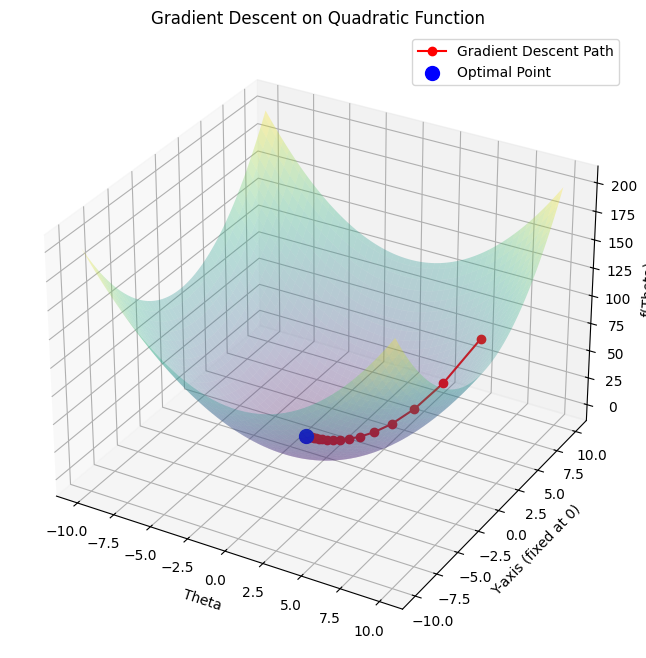

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Gradient descent function
#   theta = wektor parametrów modelu ktore model aktualizuje
def gradient_descent(f, grad_f, theta_init, learning_rate, iterations):
    theta = theta_init
    trajectory = [theta]  # Store theta values for visualization
    for i in range(iterations):
        theta -= learning_rate * grad_f(theta)
        trajectory.append(theta)
    return theta, trajectory

# Quadratic function and its gradient
# chodzi o f jak w poleceniu i grad_f to jest * (pri) np x^2 = 2x
# lambda znaczy to samo co => definiowanie funkcji
f = lambda x: x**2 + 3*x+2
grad_f = lambda x: 2*x + 3

# Parameters for gradient descent
theta_init = 10.0
learning_rate = 0.1
iterations = 20

# Perform gradient descent
optimal_theta, trajectory = gradient_descent(f, grad_f, theta_init, learning_rate, iterations)

# Create a grid for visualization
x = np.linspace(-10, 10, 400)
y = f(x)

# Prepare 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the quadratic surface
X = np.linspace(-10, 10, 100)
Y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(X, Y)
Z = X**2 + Y**2

ax.plot_surface(X, Y, Z, alpha=0.3, cmap='viridis')

# Plot trajectory
trajectory_x = trajectory
trajectory_y = np.zeros_like(trajectory)  # Single variable optimization
trajectory_z = [f(t) for t in trajectory]

ax.plot(trajectory_x, trajectory_y, trajectory_z, color='red', marker='o', label='Gradient Descent Path')
ax.scatter(optimal_theta, 0, f(optimal_theta), color='blue', s=100, label='Optimal Point')

# Labeling the plot
ax.set_xlabel("Theta")
ax.set_ylabel("Y-axis (fixed at 0)")
ax.set_zlabel("f(Theta)")
ax.set_title("Gradient Descent on Quadratic Function")
ax.legend()

plt.show()
# bazowy obrazek to jest parabola bo X^2+Y^2
# i theta mimo ze z kazda iteracja z kolejnym razem jest mniejsza i powinna isc do dolu to wizualnie idzie do gury
# bo to idzie w dol wzgedem tej paraboli

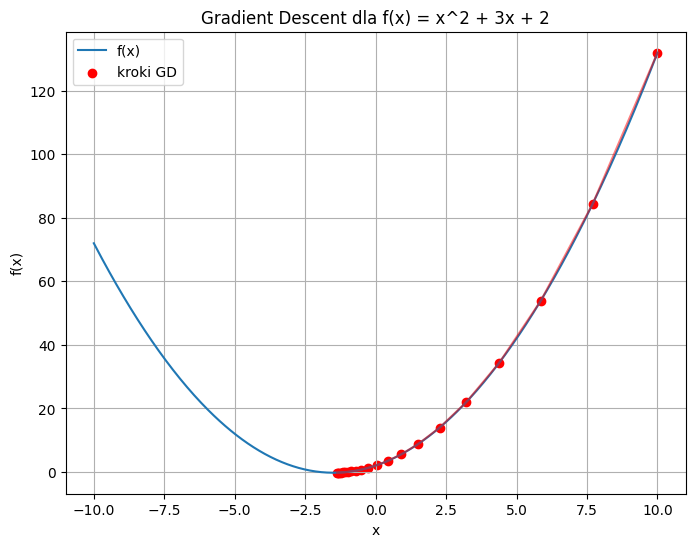

In [3]:
# Wykres 2D (to jest to, czego chcą)
plt.figure(figsize=(8,6))

# wykres funkcji
x_vals = np.linspace(-10, 10, 400)
plt.plot(x_vals, f(x_vals), label="f(x)")

# punkty gradient descent
plt.scatter(trajectory, [f(t) for t in trajectory], color='red', label='kroki GD')

# opcjonalnie linie między punktami
plt.plot(trajectory, [f(t) for t in trajectory], color='red', alpha=0.5)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent dla f(x) = x^2 + 3x + 2")
plt.legend()
plt.grid()

plt.show()

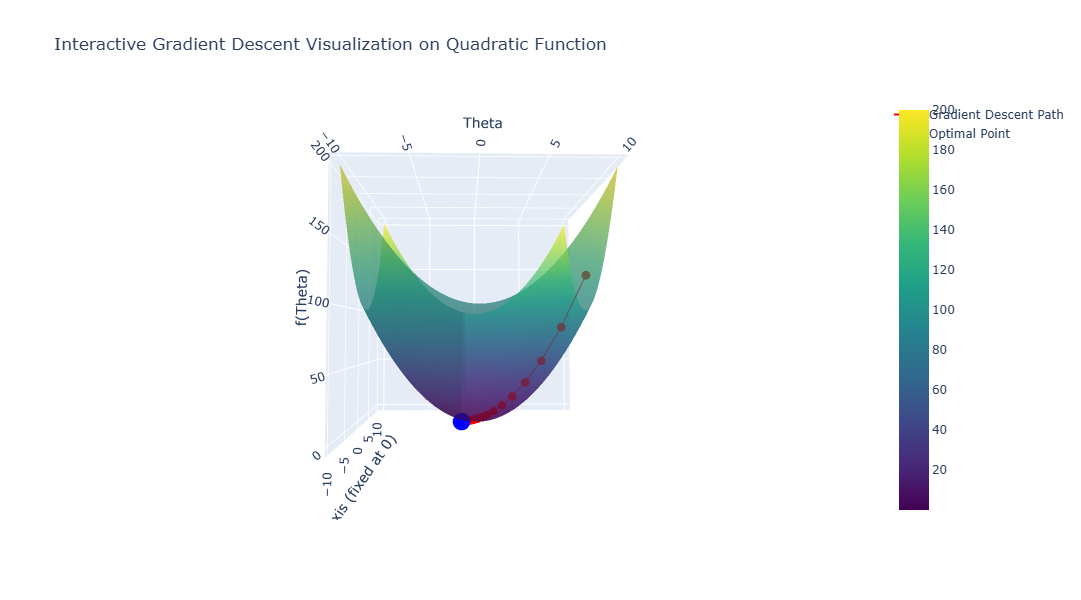

In [2]:
# Create 3D interactive plot
fig = go.Figure()

# Add surface
fig.add_trace(go.Surface(z=Z, x=X, y=Y, colorscale='Viridis', opacity=0.7, name="Quadratic Surface"))

# Add gradient descent trajectory
fig.add_trace(go.Scatter3d(
    x=trajectory_x, 
    y=trajectory_y, 
    z=trajectory_z, 
    mode='markers+lines', 
    marker=dict(size=5, color='red'),
    line=dict(color='red', width=2),
    name="Gradient Descent Path"
))

# Add optimal point
fig.add_trace(go.Scatter3d(
    x=[optimal_theta], 
    y=[0], 
    z=[f(optimal_theta)], 
    mode='markers',
    marker=dict(size=10, color='blue'),
    name="Optimal Point"
))

# Update layout
fig.update_layout(
    scene=dict(
        xaxis_title="Theta",
        yaxis_title="Y-axis (fixed at 0)",
        zaxis_title="f(Theta)",
    ),
    title="Interactive Gradient Descent Visualization on Quadratic Function",
    width=800,  # Szerokość w pikselach
    height=600,  # Wysokość w pikselach
)

# Show the interactive plot
fig.show()

# Projektowanie i trenowanie prostych sieci w TensorFlow

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Budowa modelu
model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(1)  # Warstwa wyjściowa
])

# Kompilacja modelu
# mse regresja
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Dane treningowe
X_train = np.random.rand(100, 10)
y_train = np.random.rand(100, 1)

# Trening modelu
epoch=1
model.fit(X_train, y_train, epochs=epoch, batch_size=32)

# Generowanie zbioru testowego
X_test = np.random.rand(20, 10)  # 20 próbek testowych
y_test = np.random.rand(20, 1)

# Ewaluacja modelu na zbiorze testowym
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Loss na zbiorze testowym: {loss}")
print(f"MAE na zbiorze testowym: {mae}")

# Prognozowanie dla nowych danych
new_data = np.random.rand(5, 10)  # 5 nowych próbek
predictions = model.predict(new_data)

# Wyświetlenie wyników prognozowania
print("Prognozowane wartości dla nowych danych:")
for i, prediction in enumerate(predictions):
    print(f"Przykład {i + 1}: {prediction[0]}")


Epoch 1/10
4/4 [==============================] - 1s 3ms/step - loss: 0.1711 - mae: 0.3383
Epoch 2/10
4/4 [==============================] - 0s 4ms/step - loss: 0.1182 - mae: 0.2900
Epoch 3/10
4/4 [==============================] - 0s 5ms/step - loss: 0.0976 - mae: 0.2718
Epoch 4/10
4/4 [==============================] - 0s 5ms/step - loss: 0.0955 - mae: 0.2671
Epoch 5/10
4/4 [==============================] - 0s 4ms/step - loss: 0.0985 - mae: 0.2698
Epoch 6/10
4/4 [==============================] - 0s 4ms/step - loss: 0.0985 - mae: 0.2691
Epoch 7/10
4/4 [==============================] - 0s 7ms/step - loss: 0.0945 - mae: 0.2648
Epoch 8/10
4/4 [==============================] - 0s 3ms/step - loss: 0.0896 - mae: 0.2595
Epoch 9/10
4/4 [==============================] - 0s 5ms/step - loss: 0.0860 - mae: 0.2550
Epoch 10/10
1/1 [==============================] - 0s 164ms/step - loss: 0.0551 - mae: 0.2033
Loss na zbiorze testowym: 0.05509005859494209
MAE na zbiorze testowym: 0.20325040817260

# Projektowanie i trenowanie prostych sieci w PyTorch

In [7]:
import torch
import torch.nn as nn

# Najprostszy model (regresja liniowa)
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)

model = SimpleNN()

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Dane
X_train = torch.rand(100, 10)
y_train = torch.rand(100, 1)

X_test = torch.rand(20, 10)
y_test = torch.rand(20, 1)

# Trening
epochs = 10
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    print(f"Epoka {epoch+1}, Loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    test_loss = loss_fn(y_test_pred, y_test)

print(f"Loss na zbiorze testowym: {test_loss.item():.4f}")

new_data = torch.rand(5, 10)

model.eval()
with torch.no_grad():
    predictions = model(new_data)

print("Prognozy:")
for i, pred in enumerate(predictions):
    print(f"Przykład {i+1}: {pred.item():.4f}")

Epoka 1, Loss: 0.9838
Epoka 2, Loss: 0.8762
Epoka 3, Loss: 0.7759
Epoka 4, Loss: 0.6830
Epoka 5, Loss: 0.5975
Epoka 6, Loss: 0.5197
Epoka 7, Loss: 0.4493
Epoka 8, Loss: 0.3865
Epoka 9, Loss: 0.3310
Epoka 10, Loss: 0.2827
Loss na zbiorze testowym: 0.1826
Prognozy:
Przykład 1: 0.1188
Przykład 2: 0.0057
Przykład 3: 0.0528
Przykład 4: -0.0615
Przykład 5: 0.3716


Epoka 1/5, Błąd: 0.1914
Epoka 2/5, Błąd: 0.1592
Epoka 3/5, Błąd: 0.1213
Epoka 4/5, Błąd: 0.1171
Epoka 5/5, Błąd: 0.1009


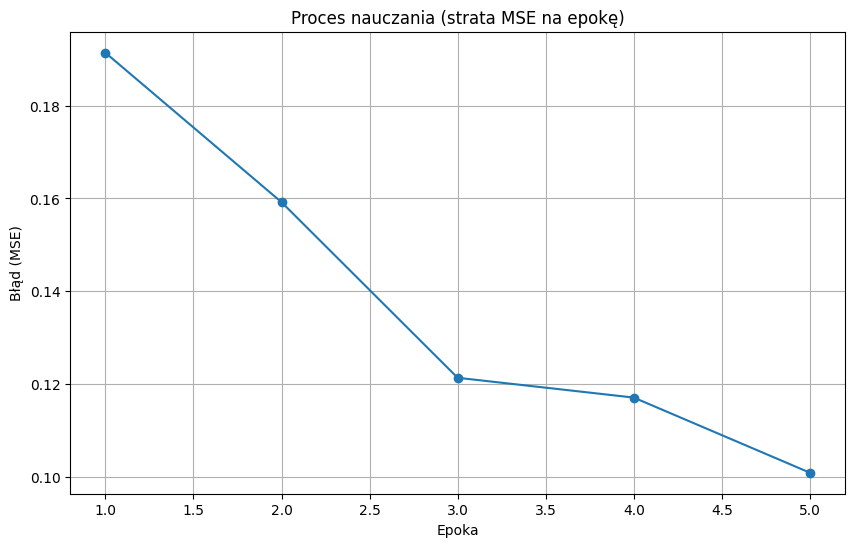

Błąd na zbiorze testowym (MSE): 0.1125


NameError: name 'transforms' is not defined

In [1]:
# z wizualizacją nauczania, ewaluacją i prognozowaniem
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST

# Definicja modelu
class SimpleNN(nn.Module):
    def __init__(self):
        #wejscie 10 cech i 64 neurony , wejsice 64 cech i 1 wynik
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
         # brak aktywacji → liczba
        return self.fc2(x)

# Inicjalizacja modelu
model = SimpleNN()

# Funkcja kosztu i optymalizator 
# MSELoss to regresja
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Dane treningowe
X_train = torch.rand(100, 10)
y_train = torch.rand(100, 1)

# Dane testowe
X_test = torch.rand(20, 10)
y_test = torch.rand(20, 1)

# Parametry trenowania
epochs = 1
batch_size = 32
num_batches = len(X_train) // batch_size
loss_history = []

# Proces nauczania
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for i in range(0, len(X_train), batch_size):
        # Pobranie batcha
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        # Forward pass
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Średni błąd dla epoki
    epoch_loss /= num_batches
    loss_history.append(epoch_loss)
    print(f"Epoka {epoch+1}/{epochs}, Błąd: {epoch_loss:.4f}")

# Wizualizacja procesu nauczania
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.xlabel('Epoka')
plt.ylabel('Błąd (MSE)')
plt.title('Proces nauczania (strata MSE na epokę)')
plt.grid()
plt.show()

# Ewaluacja na zbiorze testowym
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    test_loss = loss_fn(y_test_pred, y_test).item()
    print(f"Błąd na zbiorze testowym (MSE): {test_loss:.4f}")

# Prognozowanie dla nowych danych
# new_data = torch.rand(5, 10)  # 5 nowych próbek
# with torch.no_grad():
#     predictions = model(new_data)

# Wyświetlenie wyników prognozowania
print("Prognozowane wartości dla nowych danych:")
for i, prediction in enumerate(predictions):
    print(f"Przykład {i + 1}: {prediction.item():.4f}")


# Zastosowanie konwolucyjnych sieci neuronowych (CNN) do analizy obrazu

11490434/11490434 [==============================] - 1s 0us/step
Epoch 1/10
1875/1875 [==============================] - 59s 31ms/step - loss: 0.1299 - accuracy: 0.9604 - val_loss: 0.0636 - val_accuracy: 0.9791
Epoch 2/10
1875/1875 [==============================] - 69s 37ms/step - loss: 0.0430 - accuracy: 0.9864 - val_loss: 0.0355 - val_accuracy: 0.9879
Epoch 3/10
1875/1875 [==============================] - 76s 41ms/step - loss: 0.0303 - accuracy: 0.9905 - val_loss: 0.0271 - val_accuracy: 0.9909
Epoch 4/10
1875/1875 [==============================] - 74s 39ms/step - loss: 0.0157 - accuracy: 0.9948 - val_loss: 0.0316 - val_accuracy: 0.9901
Epoch 6/10
1875/1875 [==============================] - 79s 42ms/step - loss: 0.0120 - accuracy: 0.9964 - val_loss: 0.0329 - val_accuracy: 0.9897
Epoch 7/10
1875/1875 [==============================] - 63s 34ms/step - loss: 0.0077 - accuracy: 0.9975 - val_loss: 0.0332 - val_accuracy: 0.9918
Epoch 10/10
1875/1875 [==============================] - 59

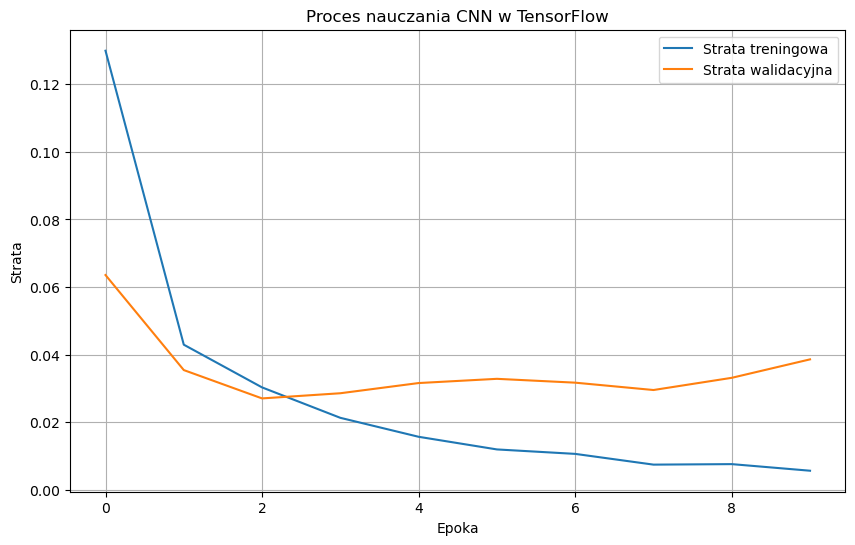

313/313 [==============================] - 3s 10ms/step - loss: 0.0386 - accuracy: 0.9915
Dokładność modelu na zbiorze testowym: 0.99%
1/1 [==============================] - 0s 189ms/step
Prognozowane etykiety dla przykładowych danych:
Przykład 1: Prognozowana etykieta: 7
Przykład 2: Prognozowana etykieta: 2
Przykład 3: Prognozowana etykieta: 1
Przykład 4: Prognozowana etykieta: 0
Przykład 5: Prognozowana etykieta: 4


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Przygotowanie danych
# to sa chyba liczby napisanie recznie i nn ma je rozpoznywac
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Przekształcanie danych
# liczba obrazów 6000 wysokość = 28 szerokość = 28 kanały = 1 (bo obraz jest czarno-biały) bo wymagane jest
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encoding etykiet
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Budowa modelu
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    #maska 2x2 przesuwa sie po obracie
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Kompilacja modelu
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Trenowanie modelu
epochs = 10
batch_size = 32
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))

# Wizualizacja procesu nauczania
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Strata treningowa')
plt.plot(history.history['val_loss'], label='Strata walidacyjna')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Proces nauczania CNN w TensorFlow')
plt.legend()
plt.grid()
plt.show()

# Testowanie modelu
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Dokładność modelu na zbiorze testowym: {accuracy:.2f}%")

# Prognozowanie dla nowych danych
new_data = X_test[:5]  # Przykładowe dane testowe
predictions = model.predict(new_data)

# Wyświetlenie wyników prognozowania
print("Prognozowane etykiety dla przykładowych danych:")
for i, prediction in enumerate(predictions):
    print(f"Przykład {i + 1}: Prognozowana etykieta: {tf.argmax(prediction).numpy()}")


# Zastosowanie konwolucyjnych sieci neuronowych (CNN) do analizy obrazu (PyTorch)

Epoka 1, Strata: 0.1324


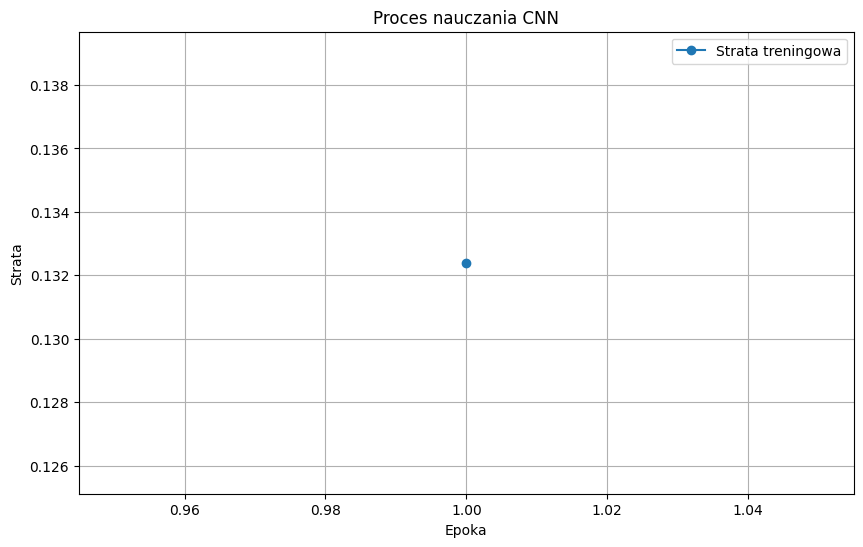

Dokładność modelu na zbiorze testowym: 98.55%


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Definicja modelu CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Przygotowanie danych
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# Inicjalizacja modelu, funkcji kosztu i optymalizatora
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Trenowanie modelu
epochs = 1
loss_history = []
for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    epoch_loss = running_loss / len(trainloader)
    loss_history.append(epoch_loss)
    print(f"Epoka {epoch + 1}, Strata: {epoch_loss:.4f}")

# Wizualizacja procesu nauczania
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', label='Strata treningowa')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Proces nauczania CNN')
plt.legend()
plt.grid()
plt.show()

# Testowanie modelu
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Dokładność modelu na zbiorze testowym: {accuracy:.2f}%")
